In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11


In [2]:
df = pd.read_csv("../data/processed/tickets_clean.csv")
print("shape:", df.shape)

shape: (28580, 16)


In [3]:
kpi = (
    df.groupby("queue")
    .agg(
        total_tickets   = ("queue",    "count"),
        high_count      = ("priority", lambda x: (x == "high").sum()),
        medium_count    = ("priority", lambda x: (x == "medium").sum()),
        low_count       = ("priority", lambda x: (x == "low").sum()),
        incident_count  = ("type",     lambda x: (x == "Incident").sum()),
        request_count   = ("type",     lambda x: (x == "Request").sum()),
    )
    .reset_index()
)

In [4]:
kpi["pct_of_total"]  = (kpi["total_tickets"] / kpi["total_tickets"].sum() * 100).round(2)
kpi["high_rate_pct"] = (kpi["high_count"] / kpi["total_tickets"] * 100).round(2)

kpi = kpi.sort_values("total_tickets", ascending=False).reset_index(drop=True)

print("=== Queue KPI Table ===")
print(kpi.to_string(index=False))

=== Queue KPI Table ===
                          queue  total_tickets  high_count  medium_count  low_count  incident_count  request_count  pct_of_total  high_rate_pct
              Technical Support           8361        4899          2536        926            4334           1684         29.25          58.59
                Product Support           5249        1554          2637       1058            2306           1196         18.37          29.61
               Customer Service           4267         805          1966       1496            1073           1969         14.93          18.87
                     IT Support           3433        1677          1451        305            1244            735         12.01          48.85
           Billing and Payments           2786         850          1334        602             674           1338          9.75          30.51
          Returns and Exchanges           1437         307           599        531             568            3

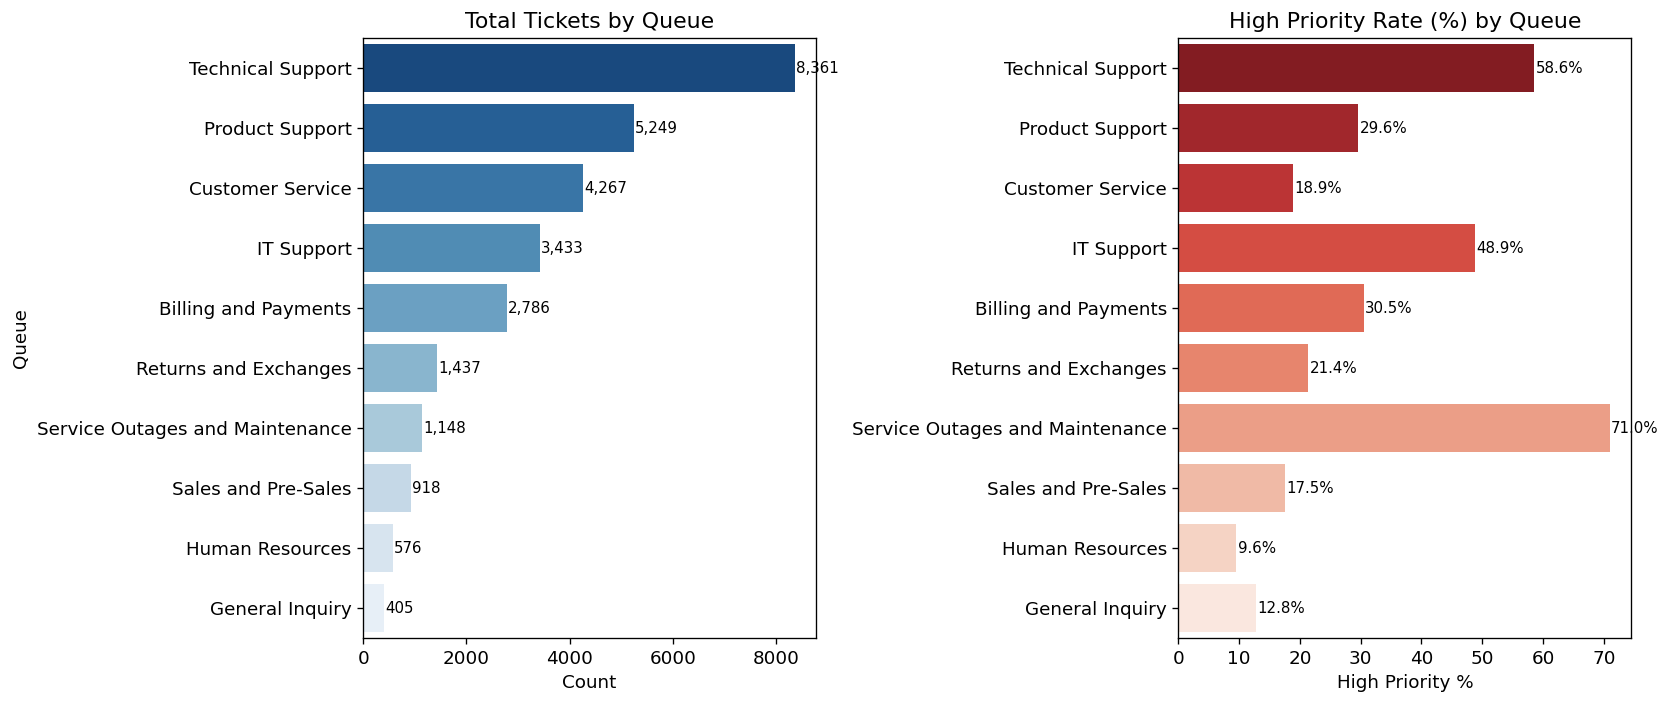

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=kpi, x="total_tickets", y="queue", palette="Blues_r", ax=axes[0])
axes[0].set_title("Total Tickets by Queue")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Queue")
for i, v in enumerate(kpi["total_tickets"]):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9)

sns.barplot(data=kpi, x="high_rate_pct", y="queue", palette="Reds_r", ax=axes[1])
axes[1].set_title("High Priority Rate (%) by Queue")
axes[1].set_xlabel("High Priority %")
axes[1].set_ylabel("")
for i, v in enumerate(kpi["high_rate_pct"]):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/02_queue_kpi.png")
plt.show()

In [7]:
lang_kpi = (
    df.groupby("language")
    .agg(
        total           = ("language", "count"),
        high_rate       = ("priority", lambda x: (x == "high").mean() * 100),
        incident_rate   = ("type",     lambda x: (x == "Incident").mean() * 100),
    )
    .round(2)
    .reset_index()
)

print("=== Language KPI ===")
print(lang_kpi)

=== Language KPI ===
  language  total  high_rate  incident_rate
0       de  12245      39.44          39.97
1       en  16335      38.84          40.23


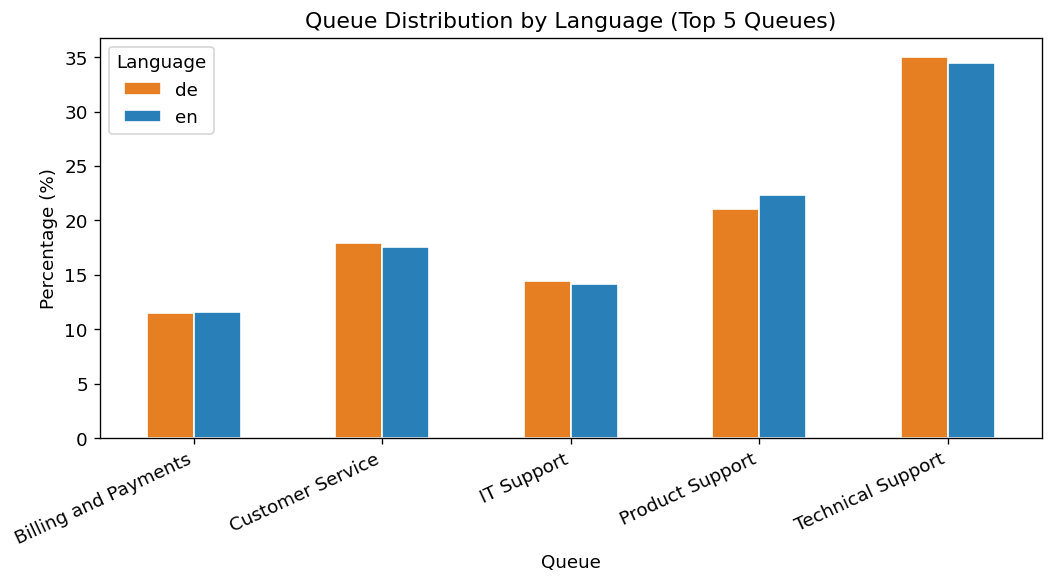

In [8]:
top5_q = df["queue"].value_counts().head(5).index
df_top5 = df[df["queue"].isin(top5_q)]

cross_lang = pd.crosstab(df_top5["queue"], df_top5["language"], normalize="columns") * 100

fig, ax = plt.subplots(figsize=(9, 5))
cross_lang.plot(kind="bar", ax=ax, color=["#e67e22", "#2980b9"], edgecolor="white")
ax.set_title("Queue Distribution by Language (Top 5 Queues)")
ax.set_xlabel("Queue")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(title="Language")
plt.tight_layout()
plt.savefig("../outputs/figures/02_queue_language_compare.png")
plt.show()

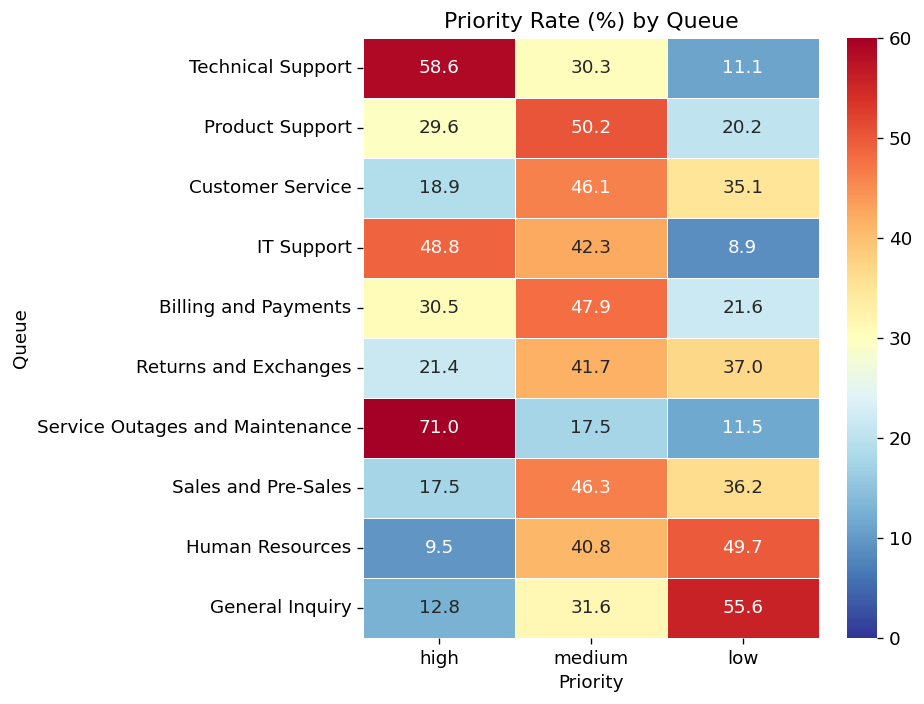

In [10]:
pivot = pd.crosstab(df["queue"], df["priority"], normalize="index") * 100
pivot = pivot[["high", "medium", "low"]]
pivot = pivot.loc[kpi["queue"].values]  # KPI 순서 유지

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot.round(1),
    annot=True,
    fmt=".1f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=60
)
ax.set_title("Priority Rate (%) by Queue")
ax.set_xlabel("Priority")
ax.set_ylabel("Queue")
plt.tight_layout()
plt.savefig("../outputs/figures/02_priority_heatmap.png")
plt.show()

In [13]:
kpi.to_csv("../data/processed/weekly_kpi.csv", index=False)


print("=== 전체 KPI 요약 ===")
print(f"총 티켓 수       : {len(df):,}")
print(f"high priority 비율: {(df['priority']=='high').mean()*100:.1f}%")
print(f"Incident 비율     : {(df['type']=='Incident').mean()*100:.1f}%")
print(f"영어 비율         : {(df['language']=='en').mean()*100:.1f}%")
print(f"독일어 비율       : {(df['language']=='de').mean()*100:.1f}%")

=== 전체 KPI 요약 ===
총 티켓 수       : 28,580
high priority 비율: 39.1%
Incident 비율     : 40.1%
영어 비율         : 57.2%
독일어 비율       : 42.8%
